In [34]:
# ============================================================
# World Cup Predictor AI - 最新データ取得版
# Google Colab用
# players.csv 手作り不要
# ============================================================

!pip -q install kagglehub

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# ============================================================
# 0. 予測したい国を設定
# ============================================================

TEAM_A = "Japan"
TEAM_B = "Netherlands"

GROUP_TEAMS = ["Japan", "Netherlands", "Sweden", "Tunisia"]

SIM_N = 10000


# ============================================================
# 1. データ取得用関数
# ============================================================

def find_file(root, filename):
    matches = glob.glob(os.path.join(root, "**", filename), recursive=True)
    return matches[0] if matches else None


def pick_col(df, candidates):
    if df is None:
        return None

    for c in candidates:
        if c in df.columns:
            return c

    return None


def download_transfermarkt_data():
    import kagglehub

    datasets = [
        "davidcariboo/player-scores",
        "mexwell/football-data-from-transfermarkt"
    ]

    for dataset in datasets:
        try:
            print(f"Downloading: {dataset}")
            path = kagglehub.dataset_download(dataset)
            print("Downloaded:", path)
            return path
        except Exception as e:
            print("Failed:", dataset)
            print(e)

    return None


def load_transfermarkt_tables(path):
    if path is None:
        return None, None, None

    players_file = find_file(path, "players.csv")
    appearances_file = find_file(path, "appearances.csv")
    valuations_file = find_file(path, "player_valuations.csv")

    print("players_file:", players_file)
    print("appearances_file:", appearances_file)
    print("valuations_file:", valuations_file)

    players = pd.read_csv(players_file) if players_file else None
    appearances = pd.read_csv(appearances_file) if appearances_file else None
    valuations = pd.read_csv(valuations_file) if valuations_file else None

    return players, appearances, valuations

In [35]:
# ============================================================
# 2. Kaggleが使えない時の予備データ
# ============================================================

def create_sample_players():
    data = [
        ["Takefusa Kubo", "Japan", "Midfield", 25, 50000000, 2400, 9, 7],
        ["Kaoru Mitoma", "Japan", "Attack", 29, 45000000, 2100, 8, 6],
        ["Wataru Endo", "Japan", "Midfield", 33, 15000000, 2300, 2, 2],
        ["Zion Suzuki", "Japan", "Goalkeeper", 23, 12000000, 2700, 0, 0],
        ["Ko Itakura", "Japan", "Defender", 29, 16000000, 2400, 2, 1],
        ["Takehiro Tomiyasu", "Japan", "Defender", 27, 35000000, 1800, 1, 2],
        ["Daichi Kamada", "Japan", "Midfield", 29, 20000000, 2200, 6, 5],
        ["Ritsu Doan", "Japan", "Attack", 28, 18000000, 2100, 7, 6],
        ["Ayase Ueda", "Japan", "Attack", 27, 10000000, 1800, 12, 2],
        ["Hidemasa Morita", "Japan", "Midfield", 31, 13000000, 2300, 3, 4],
        ["Hiroki Ito", "Japan", "Defender", 27, 25000000, 2200, 1, 3],

        ["Xavi Simons", "Netherlands", "Midfield", 23, 80000000, 2500, 11, 10],
        ["Cody Gakpo", "Netherlands", "Attack", 27, 65000000, 2600, 18, 8],
        ["Frenkie de Jong", "Netherlands", "Midfield", 29, 60000000, 2300, 3, 8],
        ["Virgil van Dijk", "Netherlands", "Defender", 34, 30000000, 2700, 4, 1],
        ["Matthijs de Ligt", "Netherlands", "Defender", 26, 55000000, 2400, 3, 1],
        ["Jurrien Timber", "Netherlands", "Defender", 25, 42000000, 2300, 2, 3],
        ["Denzel Dumfries", "Netherlands", "Defender", 30, 24000000, 2400, 5, 6],
        ["Tijjani Reijnders", "Netherlands", "Midfield", 27, 40000000, 2500, 8, 7],
        ["Memphis Depay", "Netherlands", "Attack", 32, 12000000, 1700, 12, 5],
        ["Bart Verbruggen", "Netherlands", "Goalkeeper", 23, 25000000, 2700, 0, 0],
        ["Micky van de Ven", "Netherlands", "Defender", 25, 50000000, 2500, 2, 2],

        ["Alexander Isak", "Sweden", "Attack", 26, 90000000, 2700, 24, 6],
        ["Dejan Kulusevski", "Sweden", "Midfield", 26, 55000000, 2600, 10, 11],
        ["Viktor Gyokeres", "Sweden", "Attack", 28, 75000000, 2800, 32, 8],
        ["Anthony Elanga", "Sweden", "Attack", 24, 28000000, 2300, 8, 9],
        ["Victor Lindelof", "Sweden", "Defender", 31, 12000000, 2300, 1, 1],
        ["Robin Olsen", "Sweden", "Goalkeeper", 36, 2000000, 2000, 0, 0],

        ["Ellyes Skhiri", "Tunisia", "Midfield", 31, 10000000, 2500, 3, 2],
        ["Hannibal Mejbri", "Tunisia", "Midfield", 23, 8000000, 1600, 2, 4],
        ["Aissa Laidouni", "Tunisia", "Midfield", 29, 7000000, 2300, 4, 5],
        ["Montassar Talbi", "Tunisia", "Defender", 28, 8000000, 2600, 2, 1],
        ["Youssef Msakni", "Tunisia", "Attack", 35, 1500000, 1800, 9, 5],
        ["Bechir Ben Said", "Tunisia", "Goalkeeper", 32, 1500000, 2200, 0, 0],
    ]

    df = pd.DataFrame(data, columns=[
        "player_name",
        "national_team",
        "position",
        "age",
        "market_value_in_eur",
        "minutes",
        "goals",
        "assists"
    ])

    df["passes_completed"] = 0
    df["tackles"] = 0
    df["interceptions"] = 0
    df["saves"] = 0

    return df

In [36]:
# ============================================================
# 3. 最新データから選手データを作成
# ============================================================

def build_player_features(players, appearances=None, valuations=None):
    if players is None:
        print("Kaggleデータが取れなかったのでサンプルデータを使います。")
        return create_sample_players()

    p = players.copy()

    player_id_col = pick_col(p, ["player_id", "playerId", "id"])
    name_col = pick_col(p, ["name", "player_name", "pretty_name", "full_name"])
    position_col = pick_col(p, ["position", "sub_position"])
    dob_col = pick_col(p, ["date_of_birth", "birth_date"])
    country_col = pick_col(p, ["country_of_citizenship", "country_of_birth", "citizenship"])
    mv_col = pick_col(p, ["market_value_in_eur", "highest_market_value_in_eur", "market_value"])

    if valuations is not None and player_id_col is not None:
        v = valuations.copy()

        val_player_id_col = pick_col(v, ["player_id", "playerId"])
        val_col = pick_col(v, ["market_value_in_eur", "market_value"])
        date_col = pick_col(v, ["date", "datetime"])

        if val_player_id_col and val_col:
            if date_col:
                v[date_col] = pd.to_datetime(v[date_col], errors="coerce")
                latest_v = v.sort_values(date_col).groupby(val_player_id_col).tail(1)
            else:
                latest_v = v.groupby(val_player_id_col).tail(1)

            latest_v = latest_v[[val_player_id_col, val_col]].rename(columns={
                val_player_id_col: player_id_col,
                val_col: "latest_market_value_in_eur"
            })

            p = p.merge(latest_v, on=player_id_col, how="left")
            mv_col = "latest_market_value_in_eur"

    if appearances is not None and player_id_col is not None:
        a = appearances.copy()

        app_player_id_col = pick_col(a, ["player_id", "playerId"])
        minutes_col = pick_col(a, ["minutes_played", "minutes"])
        goals_col = pick_col(a, ["goals"])
        assists_col = pick_col(a, ["assists"])

        agg = {}

        if minutes_col:
            agg[minutes_col] = "sum"
        if goals_col:
            agg[goals_col] = "sum"
        if assists_col:
            agg[assists_col] = "sum"

        if app_player_id_col and agg:
            a_agg = a.groupby(app_player_id_col).agg(agg).reset_index()

            rename = {app_player_id_col: player_id_col}

            if minutes_col:
                rename[minutes_col] = "minutes"
            if goals_col:
                rename[goals_col] = "goals"
            if assists_col:
                rename[assists_col] = "assists"

            a_agg = a_agg.rename(columns=rename)
            p = p.merge(a_agg, on=player_id_col, how="left")

    if dob_col:
        p[dob_col] = pd.to_datetime(p[dob_col], errors="coerce")
        today = pd.Timestamp.today()
        p["age"] = ((today - p[dob_col]).dt.days / 365.25).round(1)
    elif "age" not in p.columns:
        p["age"] = np.nan

    df = pd.DataFrame({
        "player_name": p[name_col] if name_col else "unknown",
        "national_team": p[country_col] if country_col else "Unknown",
        "position": p[position_col] if position_col else "Unknown",
        "age": p["age"],
        "market_value_in_eur": p[mv_col] if mv_col else 0,
        "minutes": p["minutes"] if "minutes" in p.columns else 0,
        "goals": p["goals"] if "goals" in p.columns else 0,
        "assists": p["assists"] if "assists" in p.columns else 0,
    })

    df["passes_completed"] = 0
    df["tackles"] = 0
    df["interceptions"] = 0
    df["saves"] = 0

    for col in [
        "age",
        "market_value_in_eur",
        "minutes",
        "goals",
        "assists",
        "passes_completed",
        "tackles",
        "interceptions",
        "saves"
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df = df.dropna(subset=["player_name", "national_team"])

    return df

In [37]:
# ============================================================
# 4. 選手スコアを作成
# ============================================================

def normalize_position(pos):
    pos = str(pos).lower()

    if "keeper" in pos or pos == "gk":
        return "GK"
    if "back" in pos or "def" in pos:
        return "DF"
    if "mid" in pos:
        return "MF"
    if "attack" in pos or "forward" in pos or "striker" in pos or "winger" in pos:
        return "FW"

    return "MF"


def add_player_scores(df):
    df = df.copy()

    df["log_market_value"] = np.log1p(df["market_value_in_eur"])

    for col in ["goals", "assists", "passes_completed", "tackles", "interceptions", "saves"]:
        df[f"{col}_per90"] = np.where(
            df["minutes"] > 0,
            df[col] / df["minutes"] * 90,
            0
        )

    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    score_cols = [
        "log_market_value",
        "goals_per90",
        "assists_per90",
        "passes_completed_per90",
        "tackles_per90",
        "interceptions_per90",
        "saves_per90"
    ]

    scaler = MinMaxScaler()
    df[score_cols] = scaler.fit_transform(df[score_cols])

    df["pos_group"] = df["position"].apply(normalize_position)

    def calc(row):
        pos = row["pos_group"]

        if pos == "FW":
            score = (
                row["log_market_value"] * 0.45 +
                row["goals_per90"] * 0.35 +
                row["assists_per90"] * 0.20
            )
        elif pos == "MF":
            score = (
                row["log_market_value"] * 0.45 +
                row["assists_per90"] * 0.25 +
                row["goals_per90"] * 0.15 +
                row["passes_completed_per90"] * 0.15
            )
        elif pos == "DF":
            score = (
                row["log_market_value"] * 0.65 +
                row["goals_per90"] * 0.10 +
                row["assists_per90"] * 0.10 +
                row["passes_completed_per90"] * 0.15
            )
        elif pos == "GK":
            score = (
                row["log_market_value"] * 0.80 +
                row["saves_per90"] * 0.20
            )
        else:
            score = row["log_market_value"]

        age = row["age"]

        if age == 0:
            age_factor = 1.00
        elif 24 <= age <= 29:
            age_factor = 1.05
        elif 20 <= age < 24 or 30 <= age <= 33:
            age_factor = 1.00
        else:
            age_factor = 0.92

        return score * age_factor * 100

    df["player_score"] = df.apply(calc, axis=1)

    return df

In [38]:
# ============================================================
# 5. チーム力・試合シミュレーション
# ============================================================

def team_squad(players_df, team_name, top_n=26):
    team = players_df[
        players_df["national_team"].astype(str).str.lower() == team_name.lower()
    ].copy()

    return team.sort_values("player_score", ascending=False).head(top_n)


def calculate_team_strength(players_df, team_name, verbose=False):
    squad = team_squad(players_df, team_name, 26)

    if len(squad) == 0:
        print("使える国名一覧")
        print(players_df["national_team"].value_counts().head(50))
        raise ValueError(f"{team_name} が見つかりません。国名表記を確認してください。")

    starting_11 = squad.head(11)
    bench = squad.iloc[11:26]

    starting_strength = starting_11["player_score"].sum()
    bench_strength = bench["player_score"].sum() * 0.25
    total_strength = starting_strength + bench_strength

    result = {
        "team": team_name,
        "squad_size": len(squad),
        "total_strength": total_strength,
        "starting_strength": starting_strength,
        "bench_strength": bench_strength,
        "squad_market_value": squad["market_value_in_eur"].sum()
    }

    if verbose:
        print(result)
        display(starting_11[[
            "player_name",
            "national_team",
            "position",
            "age",
            "market_value_in_eur",
            "player_score"
        ]])

    return result


def expected_goals(strength_a, strength_b, base_goal=1.30, scale=900):
    diff = strength_a - strength_b

    xg_a = base_goal + diff / scale
    xg_b = base_goal - diff / scale

    xg_a = float(np.clip(xg_a, 0.15, 4.0))
    xg_b = float(np.clip(xg_b, 0.15, 4.0))

    return xg_a, xg_b


def simulate_one_match(team_a, team_b, players_df):
    s_a = calculate_team_strength(players_df, team_a)["total_strength"]
    s_b = calculate_team_strength(players_df, team_b)["total_strength"]

    xg_a, xg_b = expected_goals(s_a, s_b)

    goals_a = np.random.poisson(xg_a)
    goals_b = np.random.poisson(xg_b)

    return goals_a, goals_b, xg_a, xg_b


def simulate_match_many(team_a, team_b, players_df, n=10000, seed=42):
    np.random.seed(seed)

    a_win = 0
    draw = 0
    b_win = 0
    scores = {}

    for _ in range(n):
        ga, gb, xg_a, xg_b = simulate_one_match(team_a, team_b, players_df)

        if ga > gb:
            a_win += 1
        elif ga == gb:
            draw += 1
        else:
            b_win += 1

        score = f"{ga}-{gb}"
        scores[score] = scores.get(score, 0) + 1

    return {
        "team_a": team_a,
        "team_b": team_b,
        "xg_a": xg_a,
        "xg_b": xg_b,
        "team_a_win_rate": a_win / n * 100,
        "draw_rate": draw / n * 100,
        "team_b_win_rate": b_win / n * 100,
        "most_common_score": max(scores, key=scores.get),
        "score_distribution": scores
    }


def plot_score_distribution(result, top_n=12):
    scores = pd.DataFrame([
        {"score": k, "count": v}
        for k, v in result["score_distribution"].items()
    ])

    scores = scores.sort_values("count", ascending=False).head(top_n)

    plt.figure(figsize=(10, 5))
    plt.bar(scores["score"], scores["count"])
    plt.title(f"{result['team_a']} vs {result['team_b']} score distribution")
    plt.xlabel("score")
    plt.ylabel("count")
    plt.xticks(rotation=45)
    plt.show()

In [39]:
# ============================================================
# 6. グループリーグシミュレーション
# ============================================================

def simulate_group_once(group_teams, players_df):
    table = {
        team: {"pts": 0, "gf": 0, "ga": 0, "gd": 0}
        for team in group_teams
    }

    fixtures = []

    for i in range(len(group_teams)):
        for j in range(i + 1, len(group_teams)):
            fixtures.append((group_teams[i], group_teams[j]))

    for a, b in fixtures:
        ga, gb, _, _ = simulate_one_match(a, b, players_df)

        table[a]["gf"] += ga
        table[a]["ga"] += gb
        table[b]["gf"] += gb
        table[b]["ga"] += ga

        if ga > gb:
            table[a]["pts"] += 3
        elif ga == gb:
            table[a]["pts"] += 1
            table[b]["pts"] += 1
        else:
            table[b]["pts"] += 3

    for team in group_teams:
        table[team]["gd"] = table[team]["gf"] - table[team]["ga"]

    ranking = sorted(
        group_teams,
        key=lambda t: (
            table[t]["pts"],
            table[t]["gd"],
            table[t]["gf"]
        ),
        reverse=True
    )

    return ranking, table


def simulate_group_many(group_teams, players_df, n=10000, seed=42):
    np.random.seed(seed)

    first_count = {team: 0 for team in group_teams}
    advance_count = {team: 0 for team in group_teams}
    points = {team: [] for team in group_teams}

    for _ in range(n):
        ranking, table = simulate_group_once(group_teams, players_df)

        first_count[ranking[0]] += 1

        for team in ranking[:2]:
            advance_count[team] += 1

        for team in group_teams:
            points[team].append(table[team]["pts"])

    result = []

    for team in group_teams:
        result.append({
            "team": team,
            "first_rate": first_count[team] / n * 100,
            "advance_rate": advance_count[team] / n * 100,
            "avg_points": np.mean(points[team])
        })

    return pd.DataFrame(result).sort_values("advance_rate", ascending=False)

In [40]:
# ============================================================
# 7. 代表戦履歴で機械学習
# ============================================================

def load_international_results():
    url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

    intl = pd.read_csv(url)
    intl["date"] = pd.to_datetime(intl["date"], errors="coerce")

    intl = intl.dropna(subset=[
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ])

    intl = intl.sort_values("date").reset_index(drop=True)

    def result(row):
        if row["home_score"] > row["away_score"]:
            return 2
        elif row["home_score"] == row["away_score"]:
            return 1
        else:
            return 0

    intl["result"] = intl.apply(result, axis=1)

    return intl


def get_recent_stats(history, team, date, n=10):
    past = history[
        ((history["home_team"] == team) | (history["away_team"] == team)) &
        (history["date"] < date)
    ].tail(n)

    if len(past) == 0:
        return {
            "win_rate": 0.33,
            "gf_avg": 1.0,
            "ga_avg": 1.0
        }

    wins = 0
    gf = []
    ga = []

    for _, r in past.iterrows():
        if r["home_team"] == team:
            team_goals = r["home_score"]
            opp_goals = r["away_score"]
        else:
            team_goals = r["away_score"]
            opp_goals = r["home_score"]

        gf.append(team_goals)
        ga.append(opp_goals)

        if team_goals > opp_goals:
            wins += 1

    return {
        "win_rate": wins / len(past),
        "gf_avg": np.mean(gf),
        "ga_avg": np.mean(ga)
    }


def build_ml_dataset(intl, since="1990-01-01"):
    base = intl[intl["date"] >= since].copy()

    rows = []

    for _, row in base.iterrows():
        date = row["date"]
        home = row["home_team"]
        away = row["away_team"]

        hist = intl[intl["date"] < date]

        hs = get_recent_stats(hist, home, date)
        aw = get_recent_stats(hist, away, date)

        rows.append({
            "home_team": home,
            "away_team": away,
            "home_win_rate": hs["win_rate"],
            "away_win_rate": aw["win_rate"],
            "home_gf_avg": hs["gf_avg"],
            "away_gf_avg": aw["gf_avg"],
            "home_ga_avg": hs["ga_avg"],
            "away_ga_avg": aw["ga_avg"],
            "win_rate_diff": hs["win_rate"] - aw["win_rate"],
            "gf_diff": hs["gf_avg"] - aw["gf_avg"],
            "ga_diff": hs["ga_avg"] - aw["ga_avg"],
            "neutral": int(row["neutral"]) if "neutral" in row else 0,
            "result": row["result"]
        })

    return pd.DataFrame(rows)


def train_ml_model(ml_df):
    features = [
        "home_win_rate",
        "away_win_rate",
        "home_gf_avg",
        "away_gf_avg",
        "home_ga_avg",
        "away_ga_avg",
        "win_rate_diff",
        "gf_diff",
        "ga_diff",
        "neutral"
    ]

    X = ml_df[features]
    y = ml_df["result"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("accuracy:", accuracy_score(y_test, pred))
    print(classification_report(
        y_test,
        pred,
        target_names=["home_loss", "draw", "home_win"]
    ))

    return model, features


def predict_ml(model, features, intl, home_team, away_team):
    date = intl["date"].max() + pd.Timedelta(days=1)
    hist = intl[intl["date"] < date]

    hs = get_recent_stats(hist, home_team, date)
    aw = get_recent_stats(hist, away_team, date)

    x = pd.DataFrame([{
        "home_win_rate": hs["win_rate"],
        "away_win_rate": aw["win_rate"],
        "home_gf_avg": hs["gf_avg"],
        "away_gf_avg": aw["gf_avg"],
        "home_ga_avg": hs["ga_avg"],
        "away_ga_avg": aw["ga_avg"],
        "win_rate_diff": hs["win_rate"] - aw["win_rate"],
        "gf_diff": hs["gf_avg"] - aw["gf_avg"],
        "ga_diff": hs["ga_avg"] - aw["ga_avg"],
        "neutral": 1
    }])

    proba = model.predict_proba(x[features])[0]

    return {
        "home_loss_rate": proba[0] * 100,
        "draw_rate": proba[1] * 100,
        "home_win_rate": proba[2] * 100
    }

=== Transfermarktデータ取得 ===
Downloading: davidcariboo/player-scores
Using Colab cache for faster access to the 'player-scores' dataset.
Downloaded: /kaggle/input/player-scores
players_file: /kaggle/input/player-scores/players.csv
appearances_file: /kaggle/input/player-scores/appearances.csv
valuations_file: /kaggle/input/player-scores/player_valuations.csv
=== 選手データ作成 ===
players_latest.csv を作成しました
(47443, 21)


,player_name,national_team,position,age,market_value_in_eur,minutes,goals,assists,player_score
19367,Gianluigi Donnarumma,Italy,Goalkeeper,27.3,45000000.0,40085.0,0.0,0.0,77.444588
21706,Diogo Costa,Portugal,Goalkeeper,26.7,40000000.0,20298.0,0.0,1.0,76.926965
16412,Gregor Kobel,Switzerland,Goalkeeper,28.5,40000000.0,24501.0,0.0,0.0,76.926965
20498,Mile Svilar,Serbia,Goalkeeper,26.8,35000000.0,13239.0,0.0,0.0,76.340131
16697,Unai Simón,Spain,Goalkeeper,29.0,30000000.0,23681.0,0.0,0.0,75.662681
29724,Joan García,Spain,Goalkeeper,25.1,30000000.0,8139.0,0.0,0.0,75.662681
27563,Giorgi Mamardashvili,Georgia,Goalkeeper,25.7,28000000.0,13775.0,0.0,0.0,75.359477
26286,Djordje Petrovic,Serbia,Goalkeeper,26.7,28000000.0,9156.0,0.0,0.0,75.359477
28839,Anatoliy Trubin,Ukraine,Goalkeeper,24.9,28000000.0,20700.0,1.0,0.0,75.359477
26185,Lucas Chevalier,France,Goalkeeper,24.6,25000000.0,12660.0,0.0,0.0,74.861428


=== 使える国名一覧 ===


,count
national_team,
Brazil,2700
Spain,2169
Italy,1993
France,1890
Argentina,1732
England,1682
Ukraine,1624
Russia,1598
Netherlands,1555


=== チーム力 ===
{'team': 'Japan', 'squad_size': 26, 'total_strength': np.float64(807.9450309202214), 'starting_strength': np.float64(632.9857235948626), 'bench_strength': np.float64(174.95930732535868), 'squad_market_value': np.float64(107750000.0)}


,player_name,national_team,position,age,market_value_in_eur,player_score
25079,Zion Suzuki,Japan,Goalkeeper,23.8,20000000.0,70.362642
27515,Leo Kokubo,Japan,Goalkeeper,25.4,4000000.0,66.807739
21504,Hiroki Ito,Japan,Defender,27.1,18000000.0,59.668722
20051,Takehiro Tomiyasu,Japan,Defender,27.6,12000000.0,58.221392
24009,Yukinari Sugawara,Japan,Defender,26.0,7500000.0,56.565234
11352,Kosuke Nakamura,Japan,Goalkeeper,31.3,700000.0,56.331310
24373,Koki Machida,Japan,Defender,28.8,7000000.0,56.281100
35837,Seiya Maikuma,Japan,Defender,28.7,3000000.0,53.275437
10952,Daniel Schmidt,Japan,Goalkeeper,34.4,1000000.0,53.198221
23010,Daiki Hashioka,Japan,Defender,27.1,2000000.0,51.827732


{'team': 'Netherlands', 'squad_size': 26, 'total_strength': np.float64(946.0516503233682), 'starting_strength': np.float64(718.5236013459133), 'bench_strength': np.float64(227.52804897745483), 'squad_market_value': np.float64(611000000.0)}


,player_name,national_team,position,age,market_value_in_eur,player_score
29858,Bart Verbruggen,Netherlands,Goalkeeper,23.8,35000000.0,72.704887
19287,Justin Bijlow,Netherlands,Goalkeeper,28.4,4000000.0,66.807739
9313,Mark Flekken,Netherlands,Goalkeeper,33.0,8000000.0,66.527552
36311,Jesper Uneken,Netherlands,Attack,21.8,600000.0,66.323443
24582,Jurriën Timber,Netherlands,Defender,25.0,70000000.0,64.525623
19857,Matthijs de Ligt,Netherlands,Defender,26.8,65000000.0,64.261669
21885,Jasper Schendelaar,Netherlands,Goalkeeper,25.8,2000000.0,63.761550
26183,Kjell Scherpen,Netherlands,Goalkeeper,26.4,2000000.0,63.761550
19316,Jeffrey de Lange,Netherlands,Goalkeeper,28.2,2000000.0,63.761550
29602,Micky van de Ven,Netherlands,Defender,25.1,55000000.0,63.665700


=== 試合シミュレーション ===
{'team_a': 'Japan', 'team_b': 'Netherlands', 'xg_a': 1.1465482006631702, 'xg_b': 1.4534517993368299, 'team_a_win_rate': 30.23, 'draw_rate': 26.68, 'team_b_win_rate': 43.09, 'most_common_score': '1-1', 'score_distribution': {'2-1': 756, '0-0': 773, '3-2': 212, '0-1': 1081, '1-2': 905, '1-0': 834, '3-0': 185, '0-2': 741, '6-0': 2, '1-1': 1232, '2-0': 499, '4-1': 79, '2-4': 95, '5-4': 2, '2-3': 238, '2-2': 545, '0-3': 346, '1-4': 158, '1-5': 45, '3-1': 268, '1-3': 419, '0-4': 133, '3-3': 109, '2-5': 23, '5-2': 15, '4-2': 52, '0-5': 42, '2-6': 8, '4-3': 24, '5-3': 8, '4-0': 54, '3-5': 14, '2-7': 2, '4-4': 9, '3-4': 23, '5-0': 9, '1-6': 14, '5-1': 14, '0-6': 10, '0-7': 1, '3-6': 5, '7-2': 2, '6-4': 1, '4-6': 2, '1-7': 2, '7-0': 1, '8-0': 1, '1-8': 1, '6-2': 2, '6-1': 2, '7-4': 1, '1-9': 1}}


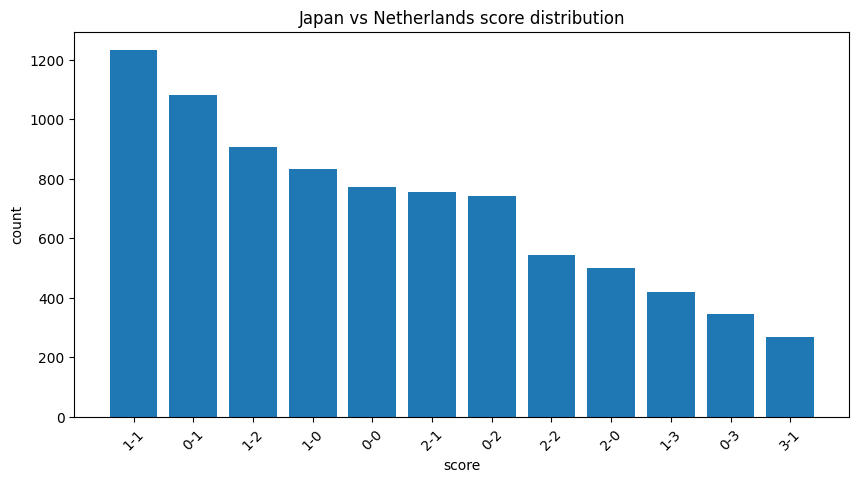

=== グループリーグシミュレーション ===


In [ ]:
# ============================================================
# 8. 実行
# ============================================================

print("=== Transfermarktデータ取得 ===")

try:
    path = download_transfermarkt_data()
    players, appearances, valuations = load_transfermarkt_tables(path)
except Exception as e:
    print("Kaggleデータ取得に失敗しました。サンプルデータで実行します。")
    print(e)
    players, appearances, valuations = None, None, None


print("=== 選手データ作成 ===")

player_features = build_player_features(players, appearances, valuations)
players_scored = add_player_scores(player_features)

players_scored.to_csv("players_latest.csv", index=False, encoding="utf-8-sig")

print("players_latest.csv を作成しました")
print(players_scored.shape)

display(players_scored[[
    "player_name",
    "national_team",
    "position",
    "age",
    "market_value_in_eur",
    "minutes",
    "goals",
    "assists",
    "player_score"
]].sort_values("player_score", ascending=False).head(20))


print("=== 使える国名一覧 ===")
display(players_scored["national_team"].value_counts().head(50))


print("=== チーム力 ===")

team_a_strength = calculate_team_strength(players_scored, TEAM_A, verbose=True)
team_b_strength = calculate_team_strength(players_scored, TEAM_B, verbose=True)


print("=== 試合シミュレーション ===")

sim_result = simulate_match_many(
    TEAM_A,
    TEAM_B,
    players_scored,
    n=SIM_N
)

print(sim_result)
plot_score_distribution(sim_result)


print("=== グループリーグシミュレーション ===")

group_result = simulate_group_many(
    GROUP_TEAMS,
    players_scored,
    n=SIM_N
)

display(group_result)

plt.figure(figsize=(8, 5))
plt.bar(group_result["team"], group_result["advance_rate"])
plt.title("Group advance probability")
plt.ylabel("Advance rate (%)")
plt.ylim(0, 100)
plt.show()


print("=== 代表戦履歴で機械学習 ===")

intl = load_international_results()
print("代表戦データの最新日:", intl["date"].max())

ml_df = build_ml_dataset(intl)
model, features = train_ml_model(ml_df)


print("=== ML予測 ===")

ml_result = predict_ml(
    model,
    features,
    intl,
    TEAM_A,
    TEAM_B
)

print(ml_result)


print("=== 選手データ版 × ML版 ブレンド予測 ===")

player_win = sim_result["team_a_win_rate"] * 0.55 + ml_result["home_win_rate"] * 0.45
draw = sim_result["draw_rate"] * 0.55 + ml_result["draw_rate"] * 0.45
opponent_win = sim_result["team_b_win_rate"] * 0.55 + ml_result["home_loss_rate"] * 0.45

total = player_win + draw + opponent_win

final_result = {
    "team_a": TEAM_A,
    "team_b": TEAM_B,
    "team_a_win_rate": player_win / total * 100,
    "draw_rate": draw / total * 100,
    "team_b_win_rate": opponent_win / total * 100,
    "most_common_score": sim_result["most_common_score"],
    "xg_a": sim_result["xg_a"],
    "xg_b": sim_result["xg_b"]
}

print(final_result)

In [ ]:
# ============================================================
# 8. 実行
# ============================================================

print("=== Transfermarktデータ取得 ===")

try:
    path = download_transfermarkt_data()
    players, appearances, valuations = load_transfermarkt_tables(path)
except Exception as e:
    print("Kaggleデータ取得に失敗しました。サンプルデータで実行します。")
    print(e)
    players, appearances, valuations = None, None, None


print("=== 選手データ作成 ===")

player_features = build_player_features(players, appearances, valuations)
players_scored = add_player_scores(player_features)

players_scored.to_csv("players_latest.csv", index=False, encoding="utf-8-sig")

print("players_latest.csv を作成しました")
print(players_scored.shape)

display(players_scored[[
    "player_name",
    "national_team",
    "position",
    "age",
    "market_value_in_eur",
    "minutes",
    "goals",
    "assists",
    "player_score"
]].sort_values("player_score", ascending=False).head(20))


print("=== 使える国名一覧 ===")
display(players_scored["national_team"].value_counts().head(50))


print("=== チーム力 ===")

team_a_strength = calculate_team_strength(players_scored, TEAM_A, verbose=True)
team_b_strength = calculate_team_strength(players_scored, TEAM_B, verbose=True)


print("=== 試合シミュレーション ===")

sim_result = simulate_match_many(
    TEAM_A,
    TEAM_B,
    players_scored,
    n=SIM_N
)

print(sim_result)
plot_score_distribution(sim_result)


print("=== グループリーグシミュレーション ===")

group_result = simulate_group_many(
    GROUP_TEAMS,
    players_scored,
    n=SIM_N
)

display(group_result)

plt.figure(figsize=(8, 5))
plt.bar(group_result["team"], group_result["advance_rate"])
plt.title("Group advance probability")
plt.ylabel("Advance rate (%)")
plt.ylim(0, 100)
plt.show()


print("=== 代表戦履歴で機械学習 ===")

intl = load_international_results()
print("代表戦データの最新日:", intl["date"].max())

ml_df = build_ml_dataset(intl)
model, features = train_ml_model(ml_df)


print("=== ML予測 ===")

ml_result = predict_ml(
    model,
    features,
    intl,
    TEAM_A,
    TEAM_B
)

print(ml_result)


print("=== 選手データ版 × ML版 ブレンド予測 ===")

player_win = sim_result["team_a_win_rate"] * 0.55 + ml_result["home_win_rate"] * 0.45
draw = sim_result["draw_rate"] * 0.55 + ml_result["draw_rate"] * 0.45
opponent_win = sim_result["team_b_win_rate"] * 0.55 + ml_result["home_loss_rate"] * 0.45

total = player_win + draw + opponent_win

final_result = {
    "team_a": TEAM_A,
    "team_b": TEAM_B,
    "team_a_win_rate": player_win / total * 100,
    "draw_rate": draw / total * 100,
    "team_b_win_rate": opponent_win / total * 100,
    "most_common_score": sim_result["most_common_score"],
    "xg_a": sim_result["xg_a"],
    "xg_b": sim_result["xg_b"]
}

print(final_result)

In [ ]:
# ============================================================
# チーム力・試合シミュレーション関数
# これを実行してから、最後の実行セルをもう一度動かす
# ============================================================

def team_squad(players_df, team_name, top_n=26):
    team = players_df[
        players_df["national_team"].astype(str).str.lower() == team_name.lower()
    ].copy()

    return team.sort_values("player_score", ascending=False).head(top_n)


def calculate_team_strength(players_df, team_name, verbose=False):
    squad = team_squad(players_df, team_name, top_n=26)

    if len(squad) == 0:
        print("使える国名一覧")
        print(players_df["national_team"].value_counts().head(80))
        raise ValueError(f"{team_name} が見つかりません。国名表記を確認してください。")

    starting_11 = squad.head(11)
    bench = squad.iloc[11:26]

    starting_strength = starting_11["player_score"].sum()
    bench_strength = bench["player_score"].sum() * 0.25
    total_strength = starting_strength + bench_strength

    result = {
        "team": team_name,
        "squad_size": len(squad),
        "total_strength": total_strength,
        "starting_strength": starting_strength,
        "bench_strength": bench_strength,
        "squad_market_value": squad["market_value_in_eur"].sum()
    }

    if verbose:
        print(result)
        display(starting_11[[
            "player_name",
            "national_team",
            "position",
            "age",
            "market_value_in_eur",
            "minutes",
            "goals",
            "assists",
            "player_score"
        ]])

    return result


def expected_goals(strength_a, strength_b, base_goal=1.30, scale=900):
    diff = strength_a - strength_b

    xg_a = base_goal + diff / scale
    xg_b = base_goal - diff / scale

    xg_a = float(np.clip(xg_a, 0.15, 4.0))
    xg_b = float(np.clip(xg_b, 0.15, 4.0))

    return xg_a, xg_b


def simulate_one_match(team_a, team_b, players_df):
    s_a = calculate_team_strength(players_df, team_a)["total_strength"]
    s_b = calculate_team_strength(players_df, team_b)["total_strength"]

    xg_a, xg_b = expected_goals(s_a, s_b)

    goals_a = np.random.poisson(xg_a)
    goals_b = np.random.poisson(xg_b)

    return goals_a, goals_b, xg_a, xg_b


def simulate_match_many(team_a, team_b, players_df, n=10000, seed=42):
    np.random.seed(seed)

    a_win = 0
    draw = 0
    b_win = 0
    scores = {}
    last_xg_a = 0
    last_xg_b = 0

    for _ in range(n):
        ga, gb, xg_a, xg_b = simulate_one_match(team_a, team_b, players_df)

        last_xg_a = xg_a
        last_xg_b = xg_b

        if ga > gb:
            a_win += 1
        elif ga == gb:
            draw += 1
        else:
            b_win += 1

        score = f"{ga}-{gb}"
        scores[score] = scores.get(score, 0) + 1

    return {
        "team_a": team_a,
        "team_b": team_b,
        "xg_a": last_xg_a,
        "xg_b": last_xg_b,
        "team_a_win_rate": a_win / n * 100,
        "draw_rate": draw / n * 100,
        "team_b_win_rate": b_win / n * 100,
        "most_common_score": max(scores, key=scores.get),
        "score_distribution": scores
    }


def plot_score_distribution(result, top_n=12):
    scores = pd.DataFrame([
        {"score": k, "count": v}
        for k, v in result["score_distribution"].items()
    ])

    scores = scores.sort_values("count", ascending=False).head(top_n)

    plt.figure(figsize=(10, 5))
    plt.bar(scores["score"], scores["count"])
    plt.title(f"{result['team_a']} vs {result['team_b']} score distribution")
    plt.xlabel("score")
    plt.ylabel("count")
    plt.xticks(rotation=45)
    plt.show()


def simulate_group_once(group_teams, players_df):
    table = {
        team: {"pts": 0, "gf": 0, "ga": 0, "gd": 0}
        for team in group_teams
    }

    fixtures = []

    for i in range(len(group_teams)):
        for j in range(i + 1, len(group_teams)):
            fixtures.append((group_teams[i], group_teams[j]))

    for a, b in fixtures:
        ga, gb, _, _ = simulate_one_match(a, b, players_df)

        table[a]["gf"] += ga
        table[a]["ga"] += gb
        table[b]["gf"] += gb
        table[b]["ga"] += ga

        if ga > gb:
            table[a]["pts"] += 3
        elif ga == gb:
            table[a]["pts"] += 1
            table[b]["pts"] += 1
        else:
            table[b]["pts"] += 3

    for team in group_teams:
        table[team]["gd"] = table[team]["gf"] - table[team]["ga"]

    ranking = sorted(
        group_teams,
        key=lambda t: (
            table[t]["pts"],
            table[t]["gd"],
            table[t]["gf"]
        ),
        reverse=True
    )

    return ranking, table


def simulate_group_many(group_teams, players_df, n=10000, seed=42):
    np.random.seed(seed)

    first_count = {team: 0 for team in group_teams}
    advance_count = {team: 0 for team in group_teams}
    points = {team: [] for team in group_teams}

    for _ in range(n):
        ranking, table = simulate_group_once(group_teams, players_df)

        first_count[ranking[0]] += 1

        for team in ranking[:2]:
            advance_count[team] += 1

        for team in group_teams:
            points[team].append(table[team]["pts"])

    result = []

    for team in group_teams:
        result.append({
            "team": team,
            "first_rate": first_count[team] / n * 100,
            "advance_rate": advance_count[team] / n * 100,
            "avg_points": np.mean(points[team])
        })

    return pd.DataFrame(result).sort_values("advance_rate", ascending=False)

In [ ]:
TEAM_A = "Japan"
TEAM_B = "Netherlands"
GROUP_TEAMS = ["Japan", "Netherlands", "Sweden", "Tunisia"]
SIM_N = 10000

print("=== チーム力 ===")
team_a_strength = calculate_team_strength(players_scored, TEAM_A, verbose=True)
team_b_strength = calculate_team_strength(players_scored, TEAM_B, verbose=True)

print("=== 試合シミュレーション ===")
sim_result = simulate_match_many(
    TEAM_A,
    TEAM_B,
    players_scored,
    n=SIM_N
)

print(sim_result)
plot_score_distribution(sim_result)

print("=== グループリーグシミュレーション ===")
group_result = simulate_group_many(
    GROUP_TEAMS,
    players_scored,
    n=SIM_N
)

display(group_result)

plt.figure(figsize=(8, 5))
plt.bar(group_result["team"], group_result["advance_rate"])
plt.title("Group advance probability")
plt.ylabel("Advance rate (%)")
plt.ylim(0, 100)
plt.show()

In [ ]:
# ============================================================
# 高速版：チーム力を最初に1回だけ計算する試合シミュレーション
# ============================================================

def simulate_match_many_fast(team_a, team_b, players_df, n=10000, seed=42):
    np.random.seed(seed)

    # チーム力は最初に1回だけ計算
    strength_a = calculate_team_strength(players_df, team_a)["total_strength"]
    strength_b = calculate_team_strength(players_df, team_b)["total_strength"]

    xg_a, xg_b = expected_goals(strength_a, strength_b)

    # 1万試合分を一気に生成
    goals_a = np.random.poisson(xg_a, n)
    goals_b = np.random.poisson(xg_b, n)

    a_win = np.sum(goals_a > goals_b)
    draw = np.sum(goals_a == goals_b)
    b_win = np.sum(goals_a < goals_b)

    scores = {}

    for ga, gb in zip(goals_a, goals_b):
        score = f"{ga}-{gb}"
        scores[score] = scores.get(score, 0) + 1

    return {
        "team_a": team_a,
        "team_b": team_b,
        "xg_a": round(xg_a, 2),
        "xg_b": round(xg_b, 2),
        "team_a_win_rate": round(a_win / n * 100, 2),
        "draw_rate": round(draw / n * 100, 2),
        "team_b_win_rate": round(b_win / n * 100, 2),
        "most_common_score": max(scores, key=scores.get),
        "score_distribution": scores
    }


result_fast = simulate_match_many_fast(
    TEAM_A,
    TEAM_B,
    players_scored,
    n=10000
)

print(result_fast)
plot_score_distribution(result_fast)

In [ ]:
# ============================================================
# 機械学習モデルを作って精度を確認するセル
# model / ml_df / features をここで作る
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ----------------------------
# 1. 代表戦データを読み込む
# ----------------------------

def load_international_results():
    url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

    intl = pd.read_csv(url)
    intl["date"] = pd.to_datetime(intl["date"], errors="coerce")

    intl = intl.dropna(subset=[
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ])

    intl = intl.sort_values("date").reset_index(drop=True)

    def result(row):
        if row["home_score"] > row["away_score"]:
            return 2  # ホーム勝ち
        elif row["home_score"] == row["away_score"]:
            return 1  # 引き分け
        else:
            return 0  # ホーム負け

    intl["result"] = intl.apply(result, axis=1)

    return intl


# ----------------------------
# 2. 直近10試合の成績を作る
# ----------------------------

def get_recent_stats(history, team, date, n=10):
    past = history[
        ((history["home_team"] == team) | (history["away_team"] == team)) &
        (history["date"] < date)
    ].tail(n)

    if len(past) == 0:
        return {
            "win_rate": 0.33,
            "gf_avg": 1.0,
            "ga_avg": 1.0
        }

    wins = 0
    gf = []
    ga = []

    for _, r in past.iterrows():
        if r["home_team"] == team:
            team_goals = r["home_score"]
            opp_goals = r["away_score"]
        else:
            team_goals = r["away_score"]
            opp_goals = r["home_score"]

        gf.append(team_goals)
        ga.append(opp_goals)

        if team_goals > opp_goals:
            wins += 1

    return {
        "win_rate": wins / len(past),
        "gf_avg": np.mean(gf),
        "ga_avg": np.mean(ga)
    }


# ----------------------------
# 3. 機械学習用データを作る
# ----------------------------

def build_ml_dataset(intl, since="2023-01-01"):
    base = intl[intl["date"] >= since].copy()

    rows = []

    for _, row in base.iterrows():
        date = row["date"]
        home = row["home_team"]
        away = row["away_team"]

        hist = intl[intl["date"] < date]

        hs = get_recent_stats(hist, home, date)
        aw = get_recent_stats(hist, away, date)

        rows.append({
            "date": date,
            "home_team": home,
            "away_team": away,

            "home_win_rate": hs["win_rate"],
            "away_win_rate": aw["win_rate"],

            "home_gf_avg": hs["gf_avg"],
            "away_gf_avg": aw["gf_avg"],

            "home_ga_avg": hs["ga_avg"],
            "away_ga_avg": aw["ga_avg"],

            "win_rate_diff": hs["win_rate"] - aw["win_rate"],
            "gf_diff": hs["gf_avg"] - aw["gf_avg"],
            "ga_diff": hs["ga_avg"] - aw["ga_avg"],

            "neutral": int(row["neutral"]) if "neutral" in row else 0,
            "result": row["result"]
        })

    return pd.DataFrame(rows)


# ----------------------------
# 4. 実行：データ作成
# ----------------------------

intl = load_international_results()
ml_df = build_ml_dataset(intl)

print("代表戦データの最新日:", intl["date"].max())
print("機械学習用データ:", ml_df.shape)

display(ml_df.head())


# ----------------------------
# 5. 特徴量と正解ラベル
# ----------------------------

features = [
    "home_win_rate",
    "away_win_rate",
    "home_gf_avg",
    "away_gf_avg",
    "home_ga_avg",
    "away_ga_avg",
    "win_rate_diff",
    "gf_diff",
    "ga_diff",
    "neutral"
]

X = ml_df[features]
y = ml_df["result"]


# ----------------------------
# 6. 訓練データとテストデータに分ける
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ----------------------------
# 7. モデル学習
# ----------------------------

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)


# ----------------------------
# 8. 精度確認
# ----------------------------

pred_test = model.predict(X_test)

acc_test = accuracy_score(y_test, pred_test)

print("テストデータでの正解率:", round(acc_test * 100, 2), "%")

print("\n分類レポート")
print(classification_report(
    y_test,
    pred_test,
    target_names=["ホーム負け", "引き分け", "ホーム勝ち"]
))

print("\n混同行列")
print(confusion_matrix(y_test, pred_test))



In [ ]:
# ============================================================
# Eloレーティングを追加した機械学習モデル
# 目標：50.62% → 53〜55%を狙う
# ============================================================

import pandas as pd
import numpy as np

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ----------------------------
# 1. Eloの期待勝率
# ----------------------------

def elo_expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


# ----------------------------
# 2. 試合ごとにEloを更新しながら、試合前Eloを保存する
# ----------------------------

def add_elo_features(intl, base_elo=1500, k=30, home_advantage=60):
    df = intl.copy()
    df = df.sort_values("date").reset_index(drop=True)

    ratings = defaultdict(lambda: base_elo)

    home_elo_list = []
    away_elo_list = []
    elo_diff_list = []
    home_expected_list = []
    away_expected_list = []

    for _, row in df.iterrows():
        home = row["home_team"]
        away = row["away_team"]

        home_elo = ratings[home]
        away_elo = ratings[away]

        # 中立地でなければホーム補正を入れる
        neutral = int(row["neutral"]) if "neutral" in row else 0
        home_adv = 0 if neutral == 1 else home_advantage

        adjusted_home_elo = home_elo + home_adv

        home_expected = elo_expected_score(adjusted_home_elo, away_elo)
        away_expected = 1 - home_expected

        home_elo_list.append(home_elo)
        away_elo_list.append(away_elo)
        elo_diff_list.append(adjusted_home_elo - away_elo)
        home_expected_list.append(home_expected)
        away_expected_list.append(away_expected)

        # 実際の結果
        if row["home_score"] > row["away_score"]:
            home_actual = 1.0
            away_actual = 0.0
        elif row["home_score"] == row["away_score"]:
            home_actual = 0.5
            away_actual = 0.5
        else:
            home_actual = 0.0
            away_actual = 1.0

        # Elo更新
        ratings[home] = home_elo + k * (home_actual - home_expected)
        ratings[away] = away_elo + k * (away_actual - away_expected)

    df["home_elo"] = home_elo_list
    df["away_elo"] = away_elo_list
    df["elo_diff"] = elo_diff_list
    df["home_expected_by_elo"] = home_expected_list
    df["away_expected_by_elo"] = away_expected_list

    return df


# ----------------------------
# 3. Elo付きの機械学習用データを作る
# ----------------------------

def build_ml_dataset_with_elo(intl, since="2023-01-01"):
    elo_df = add_elo_features(intl)

    base = elo_df[elo_df["date"] >= since].copy()

    rows = []

    for _, row in base.iterrows():
        date = row["date"]
        home = row["home_team"]
        away = row["away_team"]

        hist = intl[intl["date"] < date]

        hs10 = get_recent_stats(hist, home, date, n=10)
        aw10 = get_recent_stats(hist, away, date, n=10)

        hs5 = get_recent_stats(hist, home, date, n=5)
        aw5 = get_recent_stats(hist, away, date, n=5)

        rows.append({
            "date": date,
            "home_team": home,
            "away_team": away,

            # 直近10試合
            "home_win_rate_10": hs10["win_rate"],
            "away_win_rate_10": aw10["win_rate"],
            "home_gf_avg_10": hs10["gf_avg"],
            "away_gf_avg_10": aw10["gf_avg"],
            "home_ga_avg_10": hs10["ga_avg"],
            "away_ga_avg_10": aw10["ga_avg"],

            # 直近5試合
            "home_win_rate_5": hs5["win_rate"],
            "away_win_rate_5": aw5["win_rate"],
            "home_gf_avg_5": hs5["gf_avg"],
            "away_gf_avg_5": aw5["gf_avg"],
            "home_ga_avg_5": hs5["ga_avg"],
            "away_ga_avg_5": aw5["ga_avg"],

            # 差分
            "win_rate_diff_10": hs10["win_rate"] - aw10["win_rate"],
            "gf_diff_10": hs10["gf_avg"] - aw10["gf_avg"],
            "ga_diff_10": hs10["ga_avg"] - aw10["ga_avg"],

            "win_rate_diff_5": hs5["win_rate"] - aw5["win_rate"],
            "gf_diff_5": hs5["gf_avg"] - aw5["gf_avg"],
            "ga_diff_5": hs5["ga_avg"] - aw5["ga_avg"],

            # Elo
            "home_elo": row["home_elo"],
            "away_elo": row["away_elo"],
            "elo_diff": row["elo_diff"],
            "home_expected_by_elo": row["home_expected_by_elo"],
            "away_expected_by_elo": row["away_expected_by_elo"],

            # 会場
            "neutral": int(row["neutral"]) if "neutral" in row else 0,

            # 正解
            "result": row["result"]
        })

    return pd.DataFrame(rows)


# ----------------------------
# 4. Elo付きデータ作成
# ----------------------------

ml_df_elo = build_ml_dataset_with_elo(intl, since="2023-01-01")

print("Elo付き 機械学習用データ:", ml_df_elo.shape)
display(ml_df_elo.head())


# ----------------------------
# 5. 特徴量
# ----------------------------

features_elo = [
    # 直近10試合
    "home_win_rate_10",
    "away_win_rate_10",
    "home_gf_avg_10",
    "away_gf_avg_10",
    "home_ga_avg_10",
    "away_ga_avg_10",

    # 直近5試合
    "home_win_rate_5",
    "away_win_rate_5",
    "home_gf_avg_5",
    "away_gf_avg_5",
    "home_ga_avg_5",
    "away_ga_avg_5",

    # 差分
    "win_rate_diff_10",
    "gf_diff_10",
    "ga_diff_10",
    "win_rate_diff_5",
    "gf_diff_5",
    "ga_diff_5",

    # Elo
    "home_elo",
    "away_elo",
    "elo_diff",
    "home_expected_by_elo",
    "away_expected_by_elo",

    # 会場
    "neutral"
]

X = ml_df_elo[features_elo]
y = ml_df_elo["result"]


# ----------------------------
# 6. 訓練・テスト分割
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ----------------------------
# 7. モデル学習
# ----------------------------

model_elo = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced"
)

model_elo.fit(X_train, y_train)


# ----------------------------
# 8. 精度確認
# ----------------------------

pred_test_elo = model_elo.predict(X_test)

acc_test_elo = accuracy_score(y_test, pred_test_elo)

print("==================================================")
print("Elo追加後の機械学習モデル精度")
print("==================================================")
print(f"テストデータでの正解率：{round(acc_test_elo * 100, 2)}%")

print("\n分類レポート")
print(classification_report(
    y_test,
    pred_test_elo,
    target_names=["ホーム負け", "引き分け", "ホーム勝ち"]
))

print("\n混同行列")
print(confusion_matrix(y_test, pred_test_elo))

In [ ]:
# ============================================================
# 追加データ全部入りモデル
# Elo + 直近成績 + 大会種別 + 市場価値 + チーム戦力 + 引き分け補正
# 目標：57.98% → 60%付近を狙う
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ----------------------------
# 1. 大会種別の特徴量
# ----------------------------

def tournament_features(tournament):
    t = str(tournament).lower()

    is_friendly = int("friendly" in t)

    is_worldcup = int(
        "fifa world cup" in t
        and "qualification" not in t
        and "qualifier" not in t
    )

    is_worldcup_qualifier = int(
        "world cup qualification" in t
        or "world cup qualifier" in t
    )

    is_continental = int(
        "euro" in t
        or "asian cup" in t
        or "africa cup" in t
        or "copa américa" in t
        or "copa america" in t
        or "gold cup" in t
        or "nations league" in t
        or "afcon" in t
    )

    is_major_tournament = int(
        is_worldcup == 1
        or is_continental == 1
    )

    return {
        "is_friendly": is_friendly,
        "is_worldcup": is_worldcup,
        "is_worldcup_qualifier": is_worldcup_qualifier,
        "is_continental": is_continental,
        "is_major_tournament": is_major_tournament,
    }


# ----------------------------
# 2. チーム市場価値・チーム戦力を作る
# ----------------------------

def make_team_power_table(players_df):
    rows = []

    teams = players_df["national_team"].dropna().unique()

    for team in teams:
        try:
            squad = team_squad(players_df, team, top_n=26)

            if len(squad) == 0:
                continue

            total_value = float(squad["market_value_in_eur"].fillna(0).sum())
            avg_value = float(squad["market_value_in_eur"].fillna(0).mean())
            total_strength = float(squad["player_score"].fillna(0).sum())
            avg_strength = float(squad["player_score"].fillna(0).mean())

            rows.append({
                "team": team,
                "team_total_value": total_value,
                "team_avg_value": avg_value,
                "team_total_strength": total_strength,
                "team_avg_strength": avg_strength,
            })

        except Exception:
            continue

    return pd.DataFrame(rows)


team_power_df = make_team_power_table(players_scored)

print("チーム戦力データ:", team_power_df.shape)
display(team_power_df.sort_values("team_total_strength", ascending=False).head(10))


def get_team_power(team):
    row = team_power_df[team_power_df["team"] == team]

    if len(row) == 0:
        return {
            "team_total_value": 0,
            "team_avg_value": 0,
            "team_total_strength": 0,
            "team_avg_strength": 0,
        }

    r = row.iloc[0]

    return {
        "team_total_value": float(r["team_total_value"]),
        "team_avg_value": float(r["team_avg_value"]),
        "team_total_strength": float(r["team_total_strength"]),
        "team_avg_strength": float(r["team_avg_strength"]),
    }


# ----------------------------
# 3. 全部入りデータセットを作る
# ----------------------------

def build_ml_dataset_full(intl, since="2023-01-01"):
    elo_df = add_elo_features(intl)

    base = elo_df[elo_df["date"] >= since].copy()

    rows = []

    for _, row in base.iterrows():
        date = row["date"]
        home = row["home_team"]
        away = row["away_team"]

        hist = intl[intl["date"] < date]

        hs10 = get_recent_stats(hist, home, date, n=10)
        aw10 = get_recent_stats(hist, away, date, n=10)

        hs5 = get_recent_stats(hist, home, date, n=5)
        aw5 = get_recent_stats(hist, away, date, n=5)

        home_power = get_team_power(home)
        away_power = get_team_power(away)

        tournament = row["tournament"] if "tournament" in row else ""
        tf = tournament_features(tournament)

        value_diff = home_power["team_total_value"] - away_power["team_total_value"]
        strength_diff = home_power["team_total_strength"] - away_power["team_total_strength"]

        elo_diff_abs = abs(row["elo_diff"])
        gf_diff_10 = hs10["gf_avg"] - aw10["gf_avg"]
        ga_diff_10 = hs10["ga_avg"] - aw10["ga_avg"]
        win_rate_diff_10 = hs10["win_rate"] - aw10["win_rate"]

        # 引き分けっぽさ
        # Elo差が小さい、得点力差が小さい、勝率差が小さい、中立地なら引き分け寄り
        draw_like_score = 0

        if elo_diff_abs < 80:
            draw_like_score += 1
        if abs(gf_diff_10) < 0.35:
            draw_like_score += 1
        if abs(ga_diff_10) < 0.35:
            draw_like_score += 1
        if abs(win_rate_diff_10) < 0.15:
            draw_like_score += 1
        if int(row["neutral"]) == 1:
            draw_like_score += 1

        rows.append({
            "date": date,
            "home_team": home,
            "away_team": away,

            # 直近10試合
            "home_win_rate_10": hs10["win_rate"],
            "away_win_rate_10": aw10["win_rate"],
            "home_gf_avg_10": hs10["gf_avg"],
            "away_gf_avg_10": aw10["gf_avg"],
            "home_ga_avg_10": hs10["ga_avg"],
            "away_ga_avg_10": aw10["ga_avg"],

            # 直近5試合
            "home_win_rate_5": hs5["win_rate"],
            "away_win_rate_5": aw5["win_rate"],
            "home_gf_avg_5": hs5["gf_avg"],
            "away_gf_avg_5": aw5["gf_avg"],
            "home_ga_avg_5": hs5["ga_avg"],
            "away_ga_avg_5": aw5["ga_avg"],

            # 差分
            "win_rate_diff_10": hs10["win_rate"] - aw10["win_rate"],
            "gf_diff_10": hs10["gf_avg"] - aw10["gf_avg"],
            "ga_diff_10": hs10["ga_avg"] - aw10["ga_avg"],

            "win_rate_diff_5": hs5["win_rate"] - aw5["win_rate"],
            "gf_diff_5": hs5["gf_avg"] - aw5["gf_avg"],
            "ga_diff_5": hs5["ga_avg"] - aw5["ga_avg"],

            # Elo
            "home_elo": row["home_elo"],
            "away_elo": row["away_elo"],
            "elo_diff": row["elo_diff"],
            "elo_diff_abs": elo_diff_abs,
            "home_expected_by_elo": row["home_expected_by_elo"],
            "away_expected_by_elo": row["away_expected_by_elo"],

            # 市場価値・選手スコア
            "home_team_total_value": home_power["team_total_value"],
            "away_team_total_value": away_power["team_total_value"],
            "team_value_diff": value_diff,

            "home_team_avg_value": home_power["team_avg_value"],
            "away_team_avg_value": away_power["team_avg_value"],
            "team_avg_value_diff": home_power["team_avg_value"] - away_power["team_avg_value"],

            "home_team_total_strength": home_power["team_total_strength"],
            "away_team_total_strength": away_power["team_total_strength"],
            "team_strength_diff": strength_diff,

            "home_team_avg_strength": home_power["team_avg_strength"],
            "away_team_avg_strength": away_power["team_avg_strength"],
            "team_avg_strength_diff": home_power["team_avg_strength"] - away_power["team_avg_strength"],

            # 大会種別
            "neutral": int(row["neutral"]) if "neutral" in row else 0,
            "is_friendly": tf["is_friendly"],
            "is_worldcup": tf["is_worldcup"],
            "is_worldcup_qualifier": tf["is_worldcup_qualifier"],
            "is_continental": tf["is_continental"],
            "is_major_tournament": tf["is_major_tournament"],

            # 引き分け補正
            "draw_like_score": draw_like_score,
            "is_close_elo": int(elo_diff_abs < 80),
            "is_close_attack": int(abs(gf_diff_10) < 0.35),
            "is_close_defense": int(abs(ga_diff_10) < 0.35),
            "is_close_form": int(abs(win_rate_diff_10) < 0.15),

            # 正解
            "result": row["result"]
        })

    return pd.DataFrame(rows)


# ----------------------------
# 4. 全部入りデータ作成
# ----------------------------

ml_df_full = build_ml_dataset_full(intl, since="2023-01-01")

print("全部入り 機械学習用データ:", ml_df_full.shape)
display(ml_df_full.head())


# ----------------------------
# 5. 特徴量
# ----------------------------

features_full = [
    # 直近10試合
    "home_win_rate_10",
    "away_win_rate_10",
    "home_gf_avg_10",
    "away_gf_avg_10",
    "home_ga_avg_10",
    "away_ga_avg_10",

    # 直近5試合
    "home_win_rate_5",
    "away_win_rate_5",
    "home_gf_avg_5",
    "away_gf_avg_5",
    "home_ga_avg_5",
    "away_ga_avg_5",

    # 差分
    "win_rate_diff_10",
    "gf_diff_10",
    "ga_diff_10",
    "win_rate_diff_5",
    "gf_diff_5",
    "ga_diff_5",

    # Elo
    "home_elo",
    "away_elo",
    "elo_diff",
    "elo_diff_abs",
    "home_expected_by_elo",
    "away_expected_by_elo",

    # 市場価値・戦力
    "home_team_total_value",
    "away_team_total_value",
    "team_value_diff",
    "home_team_avg_value",
    "away_team_avg_value",
    "team_avg_value_diff",

    "home_team_total_strength",
    "away_team_total_strength",
    "team_strength_diff",
    "home_team_avg_strength",
    "away_team_avg_strength",
    "team_avg_strength_diff",

    # 大会種別
    "neutral",
    "is_friendly",
    "is_worldcup",
    "is_worldcup_qualifier",
    "is_continental",
    "is_major_tournament",

    # 引き分け補正
    "draw_like_score",
    "is_close_elo",
    "is_close_attack",
    "is_close_defense",
    "is_close_form",
]


X = ml_df_full[features_full]
y = ml_df_full["result"]


# ----------------------------
# 6. 訓練・テスト分割
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ----------------------------
# 7. モデル学習
# ----------------------------

model_full = RandomForestClassifier(
    n_estimators=700,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_full.fit(X_train, y_train)


# ----------------------------
# 8. 精度確認
# ----------------------------

pred_test_full = model_full.predict(X_test)

acc_test_full = accuracy_score(y_test, pred_test_full)

print("==================================================")
print("追加データ全部入りモデル精度")
print("==================================================")
print(f"テストデータでの正解率：{round(acc_test_full * 100, 2)}%")

print("\n分類レポート")
print(classification_report(
    y_test,
    pred_test_full,
    target_names=["ホーム負け", "引き分け", "ホーム勝ち"]
))

print("\n混同行列")
print(confusion_matrix(y_test, pred_test_full))

In [ ]:
# ============================================================
# 時間で進むサッカー試合シミュレーターAI
# 1分ごとに試合イベントを発生させる版
# ============================================================

import random
import numpy as np
import pandas as pd


def get_team_players_for_sim(players_df, team_name, top_n=11):
    """
    チームの上位選手を取得する
    """
    squad = team_squad(players_df, team_name, top_n=26)

    if len(squad) == 0:
        return []

    # ポジションごとに軽くバランスを取る
    gk = squad[squad["position"] == "Goalkeeper"].head(1)
    df = squad[squad["position"] == "Defender"].head(4)
    mf = squad[squad["position"] == "Midfield"].head(3)
    fw = squad[squad["position"] == "Attack"].head(3)

    selected = pd.concat([gk, df, mf, fw])

    # 足りない場合はスコア順で補充
    if len(selected) < top_n:
        already = set(selected["player_name"])
        extra = squad[~squad["player_name"].isin(already)].head(top_n - len(selected))
        selected = pd.concat([selected, extra])

    return selected.head(top_n).to_dict("records")


def weighted_choice_players(players):
    """
    選手スコアが高い選手ほど選ばれやすくする
    """
    if len(players) == 0:
        return None

    scores = np.array([max(float(p.get("player_score", 1)), 1) for p in players])
    probs = scores / scores.sum()

    idx = np.random.choice(len(players), p=probs)
    return players[idx]


def simulate_live_match(team_a, team_b, players_df, minutes=90, seed=42):
    """
    1分ごとに試合が進む簡易ライブシミュレーション
    """
    random.seed(seed)
    np.random.seed(seed)

    players_a = get_team_players_for_sim(players_df, team_a)
    players_b = get_team_players_for_sim(players_df, team_b)

    strength_a = calculate_team_strength(players_df, team_a)["total_strength"]
    strength_b = calculate_team_strength(players_df, team_b)["total_strength"]

    xg_a, xg_b = expected_goals(strength_a, strength_b)

    # 90分あたりの期待得点を1分あたりに変換
    goal_rate_a = xg_a / minutes
    goal_rate_b = xg_b / minutes

    score_a = 0
    score_b = 0

    log = []

    team_a_ja = COUNTRY_JA.get(team_a, team_a) if "COUNTRY_JA" in globals() else team_a
    team_b_ja = COUNTRY_JA.get(team_b, team_b) if "COUNTRY_JA" in globals() else team_b

    log.append(f"0分　試合開始：{team_a_ja} vs {team_b_ja}")

    # ボール保持率っぽいもの
    possession_a = strength_a / (strength_a + strength_b)

    for minute in range(1, minutes + 1):
        # どちらが攻撃するか
        attacking_team = team_a if random.random() < possession_a else team_b

        if attacking_team == team_a:
            attack_players = players_a
            defense_players = players_b
            team_ja = team_a_ja
            opponent_ja = team_b_ja
            goal_rate = goal_rate_a
        else:
            attack_players = players_b
            defense_players = players_a
            team_ja = team_b_ja
            opponent_ja = team_a_ja
            goal_rate = goal_rate_b

        actor = weighted_choice_players(attack_players)

        if actor is None:
            continue

        actor_name = actor["player_name"]
        actor_pos = actor["position"]
        actor_score = float(actor["player_score"])

        # イベント発生率
        event_chance = 0.18

        if random.random() > event_chance:
            continue

        # イベント種類
        event_roll = random.random()

        if event_roll < 0.45:
            log.append(f"{minute}分　{team_ja}：{actor_name} がボールをつなぐ")

        elif event_roll < 0.70:
            log.append(f"{minute}分　{team_ja}：{actor_name} が前線へパス")

        elif event_roll < 0.88:
            log.append(f"{minute}分　{team_ja}：{actor_name} がチャンスを作る")

        else:
            # シュートイベント
            shoot_bonus = actor_score / 100
            goal_probability = goal_rate * 5 * shoot_bonus

            if random.random() < goal_probability:
                if attacking_team == team_a:
                    score_a += 1
                else:
                    score_b += 1

                log.append(
                    f"{minute}分　ゴール！ {team_ja}：{actor_name} が決めた！ "
                    f"現在 {team_a_ja} {score_a}-{score_b} {team_b_ja}"
                )
            else:
                log.append(f"{minute}分　{team_ja}：{actor_name} がシュート！しかし{opponent_ja}が守る")

    log.append(f"90分　試合終了：{team_a_ja} {score_a}-{score_b} {team_b_ja}")

    if score_a > score_b:
        result = f"{team_a_ja}の勝利"
    elif score_a < score_b:
        result = f"{team_b_ja}の勝利"
    else:
        result = "引き分け"

    return {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_score": score_a,
        "team_b_score": score_b,
        "result": result,
        "log": log
    }


def show_live_match_result(match):
    """
    ライブシミュレーション結果を表示
    """
    for line in match["log"]:
        print(line)

    print("\n==============================")
    print("最終結果")
    print("==============================")
    print(f"{match['team_a_score']} - {match['team_b_score']}")
    print(match["result"])